# CEPU China Mainland - Exploratory Data Analysis

This notebook explores the China Economic Policy Uncertainty (CEPU) dataset from mainland newspapers.

**Dataset:** `cepu-china-mainland-paper.xlsx`

**Description:** Monthly Economic Policy Uncertainty index for China from 1949 onwards.

**Source:** Economic Policy Uncertainty in China Since 1949: The View from Mainland Newspapers, by Steven J. Davis, Dingqian Liu and Xuguang S. Sheng, 2019.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../../data/raw/cepu-china-mainland-paper.xlsx')
CSV_OUTPUT_PATH = Path('../../../data/raw/cepu-china-mainland-paper.csv')

## 1. Load and Clean Data

In [3]:
# Load Excel file
df_raw = pd.read_excel(DATA_PATH)

print("Raw data (first 10 rows):")
display(df_raw.head(10))

# Keep only the first 3 columns (year, month, EPU)
df = df_raw.iloc[:, :3].copy()
df.columns = ['year', 'month', 'EPU']

# Remove rows with missing EPU values
df = df.dropna(subset=['EPU'])

# Convert to appropriate types
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['EPU'] = df['EPU'].astype(float)

# Create date column
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)

Raw data (first 10 rows):


,year,month,EPU,Unnamed: 3,Unnamed: 4,"Source: ''Economic Policy Uncertainty in China Since 1949: The View from Mainland Newspapers,” by Steven J. Davis, Dingqian Liu and Xuguang S. Sheng, 2019."
0,1949,10,87.237322,NaN,NaN,These data can be used freely with attribution...
1,1949,11,40.545627,NaN,NaN,NaN
2,1949,12,40.074743,NaN,NaN,NaN
3,1950,1,39.424100,NaN,NaN,NaN
4,1950,2,200.476594,NaN,NaN,NaN
5,1950,3,87.415785,NaN,NaN,NaN
6,1950,4,173.327102,NaN,NaN,NaN
7,1950,5,90.337124,NaN,NaN,NaN
8,1950,6,668.868176,NaN,NaN,NaN
9,1950,7,266.844369,NaN,NaN,NaN



Cleaned dataset:


,year,month,EPU,date
0,1949,10,87.237322,1949-10-01
1,1949,11,40.545627,1949-11-01
2,1949,12,40.074743,1949-12-01
3,1950,1,39.424100,1950-01-01
4,1950,2,200.476594,1950-02-01



Data types:
year              int64
month             int64
EPU             float64
date     datetime64[ns]
dtype: object


## 2. Save to CSV

In [4]:
# Save cleaned data to CSV
df.to_csv(CSV_OUTPUT_PATH, index=False)
print(f"✓ Data saved to: {CSV_OUTPUT_PATH}")
print(f"  Rows saved: {len(df)}")

✓ Data saved to: ../../data/raw/cepu-china-mainland-paper.csv
  Rows saved: 349


## 3. Data Overview

In [5]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("Total months:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (349, 4)

Date range: 1949-10-01 00:00:00 to 1978-12-01 00:00:00
Total months: 349

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    349 non-null    int64         
 1   month   349 non-null    int64         
 2   EPU     349 non-null    float64       
 3   date    349 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 11.0 KB


## 4. Descriptive Statistics

In [6]:
print("Descriptive Statistics for EPU Index:")
display(df['EPU'].describe())

print("\nAdditional Statistics:")
print(f"Skewness: {df['EPU'].skew():.4f}")
print(f"Kurtosis: {df['EPU'].kurtosis():.4f}")

Descriptive Statistics for EPU Index:


count    349.000000
mean     100.000000
std      141.216934
min        0.000000
25%        0.000000
50%       46.465116
75%      154.012432
max      789.137531
Name: EPU, dtype: float64


Additional Statistics:
Skewness: 2.0010
Kurtosis: 4.4304


## 5. Time Series Visualization

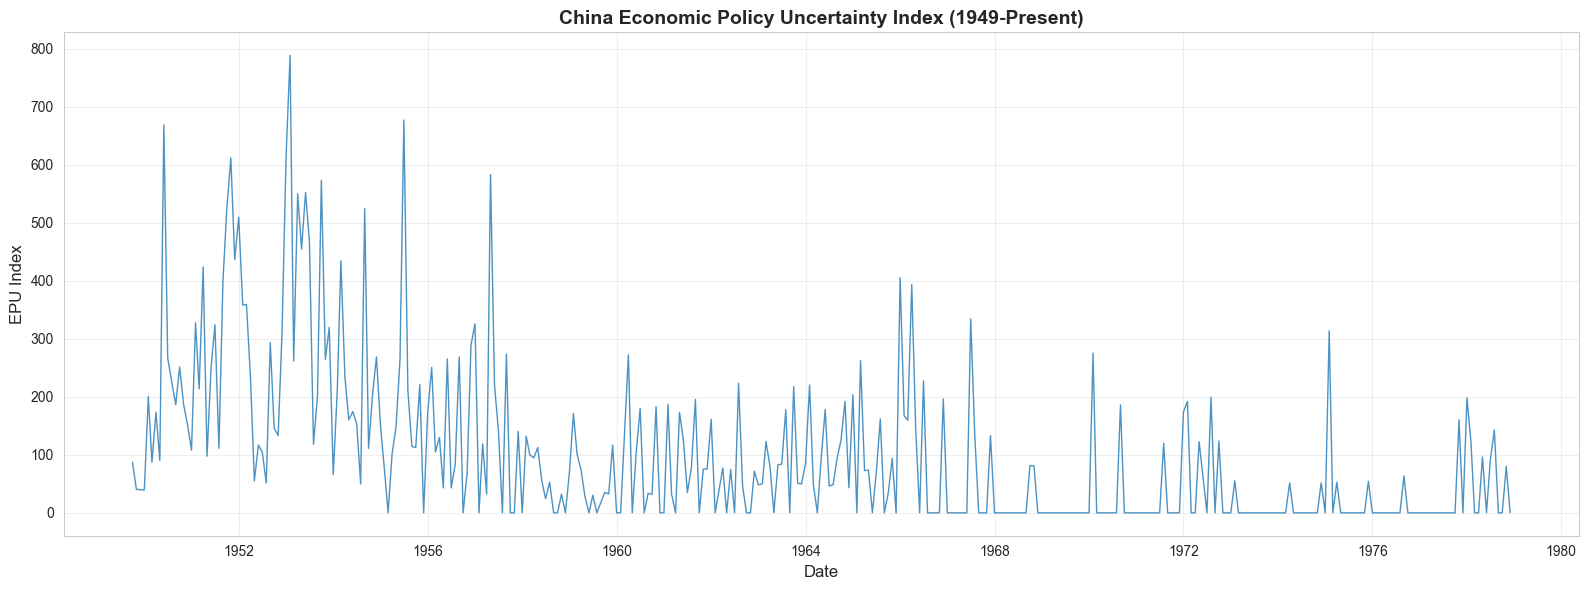

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['EPU'], linewidth=1, alpha=0.8)
ax.set_title('China Economic Policy Uncertainty Index (1949-Present)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

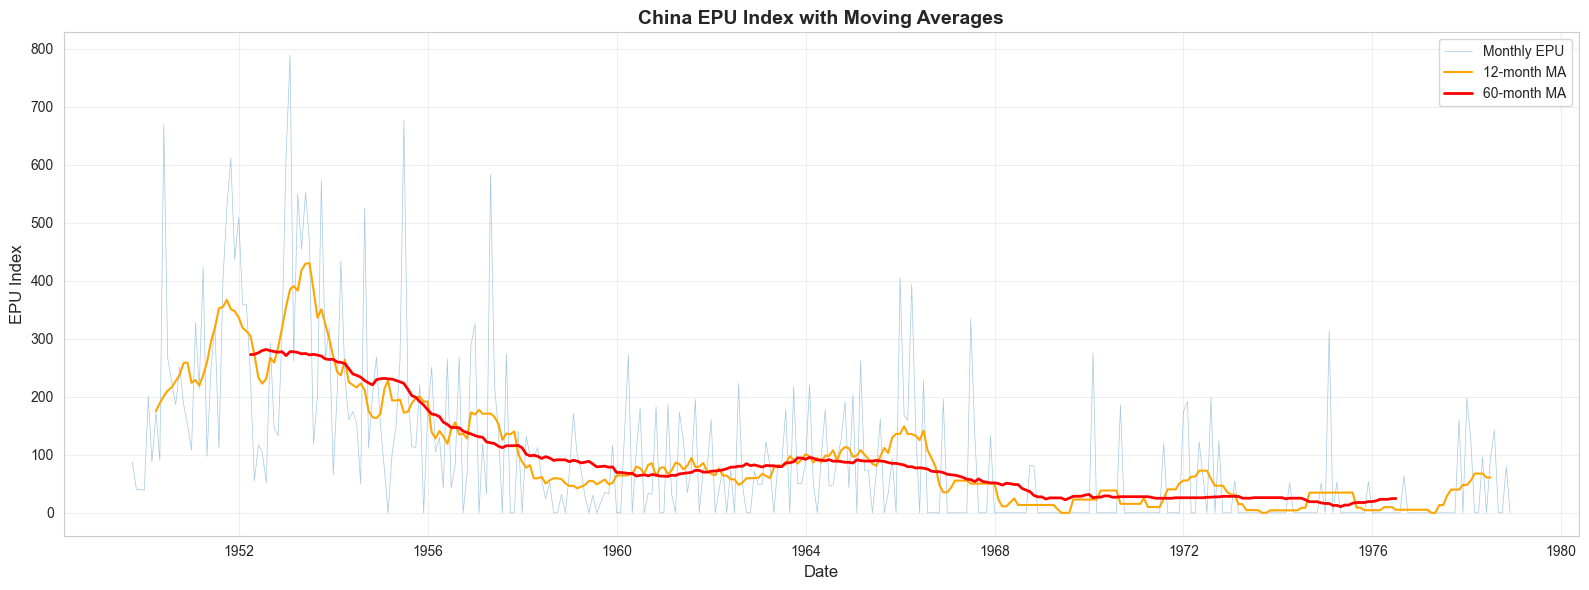

In [8]:
# With moving average
df['MA_12m'] = df['EPU'].rolling(window=12, center=True).mean()
df['MA_60m'] = df['EPU'].rolling(window=60, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['date'], df['EPU'], linewidth=0.5, alpha=0.4, label='Monthly EPU')
ax.plot(df['date'], df['MA_12m'], linewidth=1.5, label='12-month MA', color='orange')
ax.plot(df['date'], df['MA_60m'], linewidth=2, label='60-month MA', color='red')
ax.set_title('China EPU Index with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('EPU Index', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Distribution Analysis

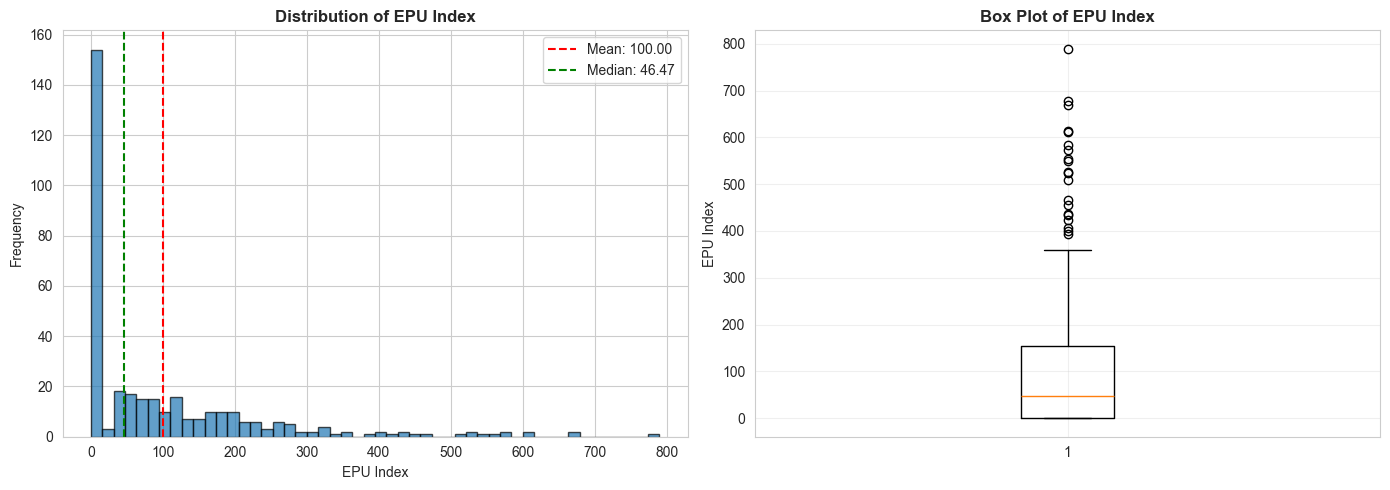

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['EPU'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['EPU'].mean(), color='red', linestyle='--', label=f'Mean: {df["EPU"].mean():.2f}')
axes[0].axvline(df['EPU'].median(), color='green', linestyle='--', label=f'Median: {df["EPU"].median():.2f}')
axes[0].set_title('Distribution of EPU Index', fontsize=12, fontweight='bold')
axes[0].set_xlabel('EPU Index')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['EPU'], vert=True)
axes[1].set_title('Box Plot of EPU Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('EPU Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Decadal Analysis

Decade Statistics:


,mean,std,min,max,count
decade,,,,,
1940,55.952564,27.094418,40.074743,87.237322,3
1950,199.049659,177.276281,0.000000,789.137531,119
1960,67.692263,89.407588,0.000000,405.479701,119
1970,27.683829,62.984495,0.000000,313.836691,108


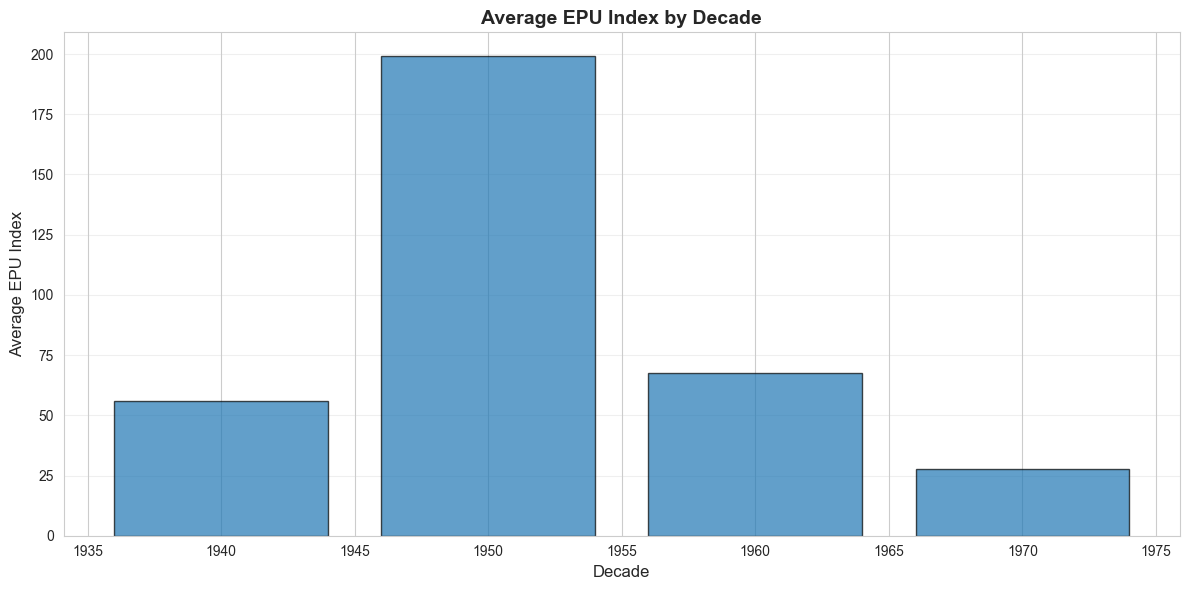

In [10]:
# Create decade column
df['decade'] = (df['year'] // 10) * 10

# Decade statistics
decade_stats = df.groupby('decade')['EPU'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Decade Statistics:")
display(decade_stats)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(decade_stats.index, decade_stats['mean'], alpha=0.7, edgecolor='black', width=8)
ax.set_title('Average EPU Index by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Average EPU Index', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Key Events

In [11]:
# Highest uncertainty periods
top_20 = df.nlargest(20, 'EPU')[['date', 'year', 'month', 'EPU']]
print("Top 20 Highest Uncertainty Periods:")
display(top_20)

Top 20 Highest Uncertainty Periods:


,date,year,month,EPU
40,1953-02-01,1953,2,789.137531
69,1955-07-01,1955,7,677.324192
8,1950-06-01,1950,6,668.868176
39,1953-01-01,1953,1,612.737178
25,1951-11-01,1951,11,611.993560
91,1957-05-01,1957,5,583.335132
48,1953-10-01,1953,10,573.214632
44,1953-06-01,1953,6,552.719998
42,1953-04-01,1953,4,550.400763
24,1951-10-01,1951,10,525.061727


## 9. Summary

In [12]:
print("=" * 60)
print("KEY FINDINGS - CHINA EPU (MAINLAND NEWSPAPERS)")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['date'].min().strftime('%Y-%m')}")
print(f"   - End: {df['date'].max().strftime('%Y-%m')}")
print(f"   - Total Months: {len(df)}")
print(f"   - Years Covered: {df['date'].max().year - df['date'].min().year + 1}")
print(f"\n2. EPU Index Statistics:")
print(f"   - Mean: {df['EPU'].mean():.2f}")
print(f"   - Median: {df['EPU'].median():.2f}")
print(f"   - Std Dev: {df['EPU'].std():.2f}")
print(f"   - Min: {df['EPU'].min():.2f} ({df.loc[df['EPU'].idxmin(), 'date'].strftime('%Y-%m')})")
print(f"   - Max: {df['EPU'].max():.2f} ({df.loc[df['EPU'].idxmax(), 'date'].strftime('%Y-%m')})")
print(f"\n3. Temporal Insights:")
print(f"   - Decade with highest avg: {decade_stats['mean'].idxmax()}s ({decade_stats['mean'].max():.2f})")
print(f"   - Decade with lowest avg: {decade_stats['mean'].idxmin()}s ({decade_stats['mean'].min():.2f})")
print(f"\n4. Data Quality:")
print(f"   - Missing Values: {df.isnull().sum().sum()}")
print(f"   - CSV file saved: {CSV_OUTPUT_PATH}")
print("\n" + "=" * 60)

KEY FINDINGS - CHINA EPU (MAINLAND NEWSPAPERS)

1. Dataset Coverage:
   - Start: 1949-10
   - End: 1978-12
   - Total Months: 349
   - Years Covered: 30

2. EPU Index Statistics:
   - Mean: 100.00
   - Median: 46.47
   - Std Dev: 141.22
   - Min: 0.00 (1955-03)
   - Max: 789.14 (1953-02)

3. Temporal Insights:
   - Decade with highest avg: 1950s (199.05)
   - Decade with lowest avg: 1970s (27.68)

4. Data Quality:
   - Missing Values: 70
   - CSV file saved: ../../data/raw/cepu-china-mainland-paper.csv

